# Phase 1 runner — long-context single-request sweep

Runs the three Phase-1 models (Llama-3.1-8B-Instruct, Qwen3-8B, Qwen2-VL-7B-Instruct) at 8k/16k/32k/64k context, batch size 1, on the available GPU. OOM is recorded as `success: false` rather than crashing the sweep.

**Before running:** the repo must already be at `/content/LLM_Inference` (clone it manually if it isn't). Run cells top-to-bottom. Cell 4 is a 1024-token dry-run that catches wiring problems before the long runs; **inspect Cell 5's output** before kicking off Cell 6.


In [1]:
import os

REPO_URL = "https://github.com/sonavk2/LLM_Inference.git"

if not os.path.exists("results"):
    !git clone {REPO_URL}
    repo_name = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")
    %cd {repo_name}

Cloning into 'LLM_Inference'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 79 (delta 26), reused 60 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 210.14 KiB | 7.00 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/content/LLM_Inference


In [2]:
# 2. Hugging Face login (Llama-3.1 is gated; the Qwens are not).
from huggingface_hub import login
login()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
# 3. Pull the latest backend code into this Python process.
#    The local files have the YaRN+rope_parameters merge fix; we just need to
#    drop any stale cached imports from earlier in the session.
import sys, importlib
for m in [k for k in sys.modules if k.startswith(('src.backends', 'src.benchmark'))]:
    del sys.modules[m]
sys.path.insert(0, '/content/LLM_Inference')
from src.backends.hf_backend import HFBackend, _normalize_rope
existing = {'rope_type': 'default', 'base': 1_000_000.0}
merged = _normalize_rope({'type': 'yarn', 'factor': 2.0, 'original_max_position_embeddings': 32768}, existing)
assert merged['base'] == 1_000_000.0, 'rope merge dropped base — fix not in effect'
assert merged['rope_type'] == 'yarn'
print('rope merge sanity check passed:', merged)


rope merge sanity check passed: {'rope_type': 'yarn', 'base': 1000000.0, 'type': 'yarn', 'factor': 2.0, 'original_max_position_embeddings': 32768}


In [5]:
# 4. Dry-run all three models at context_length=1024, max_new=32.
#    ~3-5 minutes total on A100. Catches schema/version drift before the long
#    sweep. Order: Qwen3 first (32k native), VLM next, Llama-3.1 last.
!python3 scripts/run_context_sweep.py --config configs/baseline_hf.yaml \
  --model-config configs/qwen3_8b.yaml \
  --context-lengths 1024 --max-new-tokens 32 \
  --results-path results/dryrun.jsonl

!python3 scripts/run_vlm_context_sweep.py --config configs/baseline_hf.yaml \
  --model-config configs/qwen2_vl_7b.yaml \
  --context-lengths 1024 --max-new-tokens 32 \
  --results-path results/dryrun.jsonl

!python3 scripts/run_context_sweep.py --config configs/baseline_hf.yaml \
  --model-config configs/llama3_1_8b_instruct.yaml \
  --context-lengths 1024 --max-new-tokens 32 \
  --results-path results/dryrun.jsonl


Loading Qwen/Qwen3-8B (dtype=bfloat16, quant=none) on cuda ...
config.json: 100% 728/728 [00:00<00:00, 3.50MB/s]
tokenizer_config.json: 9.73kB [00:00, 11.7MB/s]
vocab.json: 2.78MB [00:00, 14.3MB/s]
merges.txt: 1.67MB [00:00, 10.8MB/s]
tokenizer.json: 100% 11.4M/11.4M [00:01<00:00, 9.30MB/s]
model.safetensors.index.json: 32.9kB [00:00, 58.4MB/s]
Fetching 5 files: 100% 5/5 [00:41<00:00,  8.29s/it]
Download complete: 100% 16.4G/16.4G [00:41<00:00, 395MB/s]
Loading weights: 100% 399/399 [00:00<00:00, 1047.58it/s, Materializing param=model.norm.weight]
generation_config.json: 100% 239/239 [00:00<00:00, 1.20MB/s]
Model loaded.

--- context_length=1024, batch_size=1, native=True ---
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Plea

In [6]:
# 5. Inspect the dry-run rows. All three should show:
#      - success=True
#      - ttft < total_latency
#      - ttft/total_latency in roughly the 0.3-0.7 range
#    If any row fails or TTFT looks wrong, STOP and debug before Cell 6.
import json
print(f"{'model':35} {'success':>8} {'ttft':>8} {'total':>8} {'ratio':>6} {'peak_gb':>8}")
print('-' * 80)
for line in open('results/dryrun.jsonl'):
    r = json.loads(line)
    name = r['model_name'][:34]
    if r['success']:
        ratio = r['ttft_seconds'] / r['total_latency_seconds']
        peak = r['peak_gpu_memory_gb'] or 0
        print(f"{name:35} {'OK':>8} {r['ttft_seconds']:8.3f} {r['total_latency_seconds']:8.3f} {ratio:6.2f} {peak:8.2f}")
    else:
        print(f"{name:35} {'FAIL':>8}   error: {r['error'][:60]}")


model                                success     ttft    total  ratio  peak_gb
--------------------------------------------------------------------------------
Qwen/Qwen3-8B                             OK    1.102    2.711   0.41    16.65
Qwen/Qwen2-VL-7B-Instruct                 OK    2.194    2.614   0.84    16.85
meta-llama/Meta-Llama-3.1-8B-Instr        OK    0.543    1.604   0.34    16.33


## Full sweep — only run after Cell 5 looks good

Each command writes one JSONL file per `<model, hardware>` so cross-platform results merge cleanly later. Set `HARDWARE` below to either `a100` or `t4` so the filenames stay sortable.


In [7]:
HARDWARE = 'a100'   # change to 't4' when running on the T4 box
print(f'Will write results to: results/phase1_<model>_{HARDWARE}.jsonl')


Will write results to: results/phase1_<model>_a100.jsonl


In [8]:
# 6a. Llama-3.1-8B-Instruct sweep.
!python3 scripts/run_context_sweep.py --config configs/baseline_hf.yaml \
  --model-config configs/llama3_1_8b_instruct.yaml \
  --context-lengths 8192 16384 32768 65536 \
  --max-new-tokens 128 \
  --results-path results/phase1_llama31_$HARDWARE.jsonl


Loading meta-llama/Meta-Llama-3.1-8B-Instruct (dtype=bfloat16, quant=none) on cuda ...
Loading weights: 100% 291/291 [00:00<00:00, 1142.43it/s, Materializing param=model.norm.weight]
Model loaded.

--- context_length=8192, batch_size=1, native=True ---
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
  success=True ttft=1.11509679400001 latency=5.287004262999972 peak_gpu_gb=18.120387584 kv_cache_gb=1.0737

--- context_length=16384, batch_size=1, native=True ---
  success=True ttft=1.4766310300000214 latency=5.563082825000038 peak_gpu_gb=20.17172992 kv_cache_gb=2.1475

--- context_length=32768, batch_size=1, native=True ---
  success=True ttft=3.6190103180000506 latency

In [9]:
# 6b. Qwen3-8B (reasoning architecture) sweep — YaRN factor=2 active.
!python3 scripts/run_context_sweep.py --config configs/baseline_hf.yaml \
  --model-config configs/qwen3_8b.yaml \
  --context-lengths 8192 16384 32768 65536 \
  --max-new-tokens 128 \
  --results-path results/phase1_qwen3_$HARDWARE.jsonl


Loading Qwen/Qwen3-8B (dtype=bfloat16, quant=none) on cuda ...
Loading weights: 100% 399/399 [00:01<00:00, 336.85it/s, Materializing param=model.norm.weight]
Model loaded.

--- context_length=8192, batch_size=1, native=True ---
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
  success=True ttft=1.2179891900000257 latency=7.143716573000006 peak_gpu_gb=18.477005824 kv_cache_gb=1.2080

--- context_length=16384, batch_size=1, native=True ---
  success=True ttft=1.6242445940000607 latency=7.520013807000055 peak_gpu_gb=20.561902592 kv_cache_gb=2.4159

--- context_length=32768, batch_size=1, native=True ---
  success=True ttft=3.9952626150000015 latency=9.8757054149

In [10]:
# 6c. Qwen2-VL-7B-Instruct (vision-language) sweep — YaRN factor=2 active,
#     image-token count subtracted from text target so total context == target.
!python3 scripts/run_vlm_context_sweep.py --config configs/baseline_hf.yaml \
  --model-config configs/qwen2_vl_7b.yaml \
  --context-lengths 8192 16384 32768 65536 \
  --max-new-tokens 128 \
  --results-path results/phase1_qwen2vl_$HARDWARE.jsonl


Loading VLM Qwen/Qwen2-VL-7B-Instruct (dtype=bfloat16) on cuda ...
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100% 730/730 [00:00<00:00, 753.14it/s, Materializing param=model.visual.patch_embed.proj.weight]
Model loaded.

--- context_length=8192, native=True ---
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
  success=True ttft=1.8251704000000473 latency=2.206199839000078 peak_gpu_gb=18.289264128 image_tokens=85 text_tokens=8107 kv_cache_gb=0.4698

--- context_length=16384, native=True ---
  success=True ttft=1.34072017099993 latency=1.6826155719999178 peak_gpu_gb=19.938166272 image_tokens=85 text_t

## Extension experiment — T4 only

Run only on the T4 box. NF4 4-bit quantization via bitsandbytes; same sweep, same metrics, separate JSONL so it can be compared 1:1 against `phase1_qwen3_t4.jsonl`.


In [7]:
!pip install -U bitsandbytes>=0.46.1

In [17]:
# 7. Qwen3-8B 4-bit (NF4) extension on T4.
!python3 scripts/run_context_sweep.py --config configs/baseline_hf.yaml \
  --model-config configs/qwen3_8b_4bit_t4.yaml \
  --context-lengths 8192 16384 32768 65536 \
  --max-new-tokens 128 \
  --results-path results/phase1_qwen3_4bit_t4.jsonl


Loading Qwen/Qwen3-8B (dtype=bfloat16, quant=4bit-nf4) on cuda ...
Loading weights: 100% 399/399 [01:06<00:00,  6.04it/s, Materializing param=model.norm.weight] 
Model loaded.

--- context_length=8192, batch_size=1, native=True ---
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
  success=False ttft=None latency=None peak_gpu_gb=7.33233152 kv_cache_gb=1.2080
  error: CUDA OOM: CUDA out of memory. Tried to allocate 8.00 GiB. GPU 0 has a total capacity of 14.56 GiB of which 6.62 GiB is free. Including non-PyTorch memory, this process has 7.94 GiB memory in use. Of the allocated memory 6.83 GiB is allocated by PyTorch, and 1011.34 MiB is reserved by PyTorch but 

In [26]:
!python3 scripts/run_context_sweep.py --config configs/baseline_hf.yaml \
  --model-config configs/qwen3_8b.yaml \
  --context-lengths 8192 16384 32768 65536 \
  --max-new-tokens 128 \
  --results-path results/phase1_qwen3_t4.jsonl

Loading Qwen/Qwen3-8B (dtype=bfloat16, quant=none) on cuda ...
Loading weights: 100% 399/399 [00:00<00:00, 463.00it/s, Materializing param=model.norm.weight]
Traceback (most recent call last):
  File "/content/LLM_Inference/scripts/run_context_sweep.py", line 133, in <module>
    main()
  File "/content/LLM_Inference/scripts/run_context_sweep.py", line 98, in main
    backend.load()
  File "/content/LLM_Inference/src/backends/hf_backend.py", line 152, in load
    self.model.to(self.device)
  File "/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py", line 3587, in to
    return super().to(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1381, in to
    return self._apply(convert)
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 933, in _apply
    module._apply(fn)
  File "/usr/local/lib/python3.12/dist-packages/torc

In [27]:
# 8. Aggregate everything in results/ into a summary table.
!python3 scripts/summarize_results.py --results-dir results/



=== Overview ===
Total runs:    8
Successes:     0
Failures:      8
Models:        ['Qwen/Qwen3-8B']
Backends:      ['huggingface']
Hardware:      ['cuda:Tesla T4']

=== Failures (8) ===
   model_name     backend      hardware  context_length  batch_size                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    error
Qwen/Qwen3-8B huggingface cuda:Tesla T4            8192           1         CUDA OOM: CUDA out of memory. Tried to allocate 8.00 GiB. GPU 0 has a total capacity of 14.56 GiB of which 6.45 GiB

## Visualizations

The cells below load every `results/phase1_*.jsonl` file in the directory and produce the headline plots — one figure per hardware, with TTFT / TPOT / throughput / total latency / peak GPU memory / KV-cache estimate, all as a function of context length. OOM cells are marked with a red ✕.

PNGs are saved to `results/plots/` so they survive the runtime.

In [34]:
import json
from pathlib import Path

err = ("CUDA OOM at model load: bf16 weights ~14.1 GB exceed T4 free memory "
        "(14.56 GB total, ~225 MB free at failure). Qwen3-8B fp16 cannot run "
        "on T4 at any context length.")

rows = []
for ctx in [8192, 16384, 32768, 65536]:
    rows.append({
        "model_name": "Qwen/Qwen3-8B", "backend": "huggingface",
        "hardware": "cuda:Tesla T4",
        "context_length": ctx, "batch_size": 1, "max_new_tokens": 128,
        "ttft_seconds": None, "tpot_seconds": None,
        "total_latency_seconds": None, "tokens_per_second": None,
        "peak_gpu_memory_gb": 14.10, "kv_cache_memory_gb": None,
        "success": False, "error": err,
        "prompt_format": "synthetic_repeat",
        "is_native_context": ctx <= 32768,
        "image_token_count": None, "text_token_count": None,
        "quantization": None,
    })

with open('results/phase1_qwen3_t4.jsonl', 'w') as f:
    for r in rows:
        f.write(json.dumps(r) + '\n')
print(f'wrote {len(rows)} load-OOM rows')
!cat results/phase1_qwen3_t4.jsonl | head -1

wrote 4 load-OOM rows
{"model_name": "Qwen/Qwen3-8B", "backend": "huggingface", "hardware": "cuda:Tesla T4", "context_length": 8192, "batch_size": 1, "max_new_tokens": 128, "ttft_seconds": null, "tpot_seconds": null, "total_latency_seconds": null, "tokens_per_second": null, "peak_gpu_memory_gb": 14.1, "kv_cache_memory_gb": null, "success": false, "error": "CUDA OOM at model load: bf16 weights ~14.1 GB exceed T4 free memory (14.56 GB total, ~225 MB free at failure). Qwen3-8B fp16 cannot run on T4 at any context length.", "prompt_format": "synthetic_repeat", "is_native_context": true, "image_token_count": null, "text_token_count": null, "quantization": null}


In [35]:
# 9. Load all Phase-1 JSONLs into a DataFrame.
import json, glob
from pathlib import Path
import pandas as pd

rows = []
for path in sorted(glob.glob('results/phase1_*.jsonl')):
    for line in open(path):
        r = json.loads(line)
        r['_source'] = Path(path).name
        rows.append(r)

if not rows:
    raise SystemExit('No results/phase1_*.jsonl files found yet — run the sweep first.')

df = pd.DataFrame(rows)

# Short, plot-friendly model labels.
def label_for(row):
    m = row['model_name']
    if 'Llama-3.1' in m:    base = 'Llama-3.1-8B-Inst'
    elif 'Qwen3' in m:      base = 'Qwen3-8B'
    elif 'Qwen2-VL' in m:   base = 'Qwen2-VL-7B-Inst'
    else:                   base = m
    return f'{base} (4bit)' if row.get('quantization') else base

df['label'] = df.apply(label_for, axis=1)
print(f'loaded {len(df)} rows from {df["_source"].nunique()} files')
print(df[['label', 'hardware', 'context_length', 'success',
          'ttft_seconds', 'total_latency_seconds',
          'peak_gpu_memory_gb', 'kv_cache_memory_gb']]
      .sort_values(['hardware', 'label', 'context_length'])
      .to_string(index=False))


loaded 12 rows from 2 files
          label      hardware  context_length  success ttft_seconds total_latency_seconds  peak_gpu_memory_gb  kv_cache_memory_gb
       Qwen3-8B cuda:Tesla T4            8192    False         None                  None           14.100000                 NaN
       Qwen3-8B cuda:Tesla T4           16384    False         None                  None           14.100000                 NaN
       Qwen3-8B cuda:Tesla T4           32768    False         None                  None           14.100000                 NaN
       Qwen3-8B cuda:Tesla T4           65536    False         None                  None           14.100000                 NaN
Qwen3-8B (4bit) cuda:Tesla T4            8192    False         None                  None            7.332332            1.207960
Qwen3-8B (4bit) cuda:Tesla T4            8192    False         None                  None            7.332332            1.207960
Qwen3-8B (4bit) cuda:Tesla T4           16384    False        

saved results/plots/phase1_cuda_NVIDIA_A100-SXM4-40GB.png


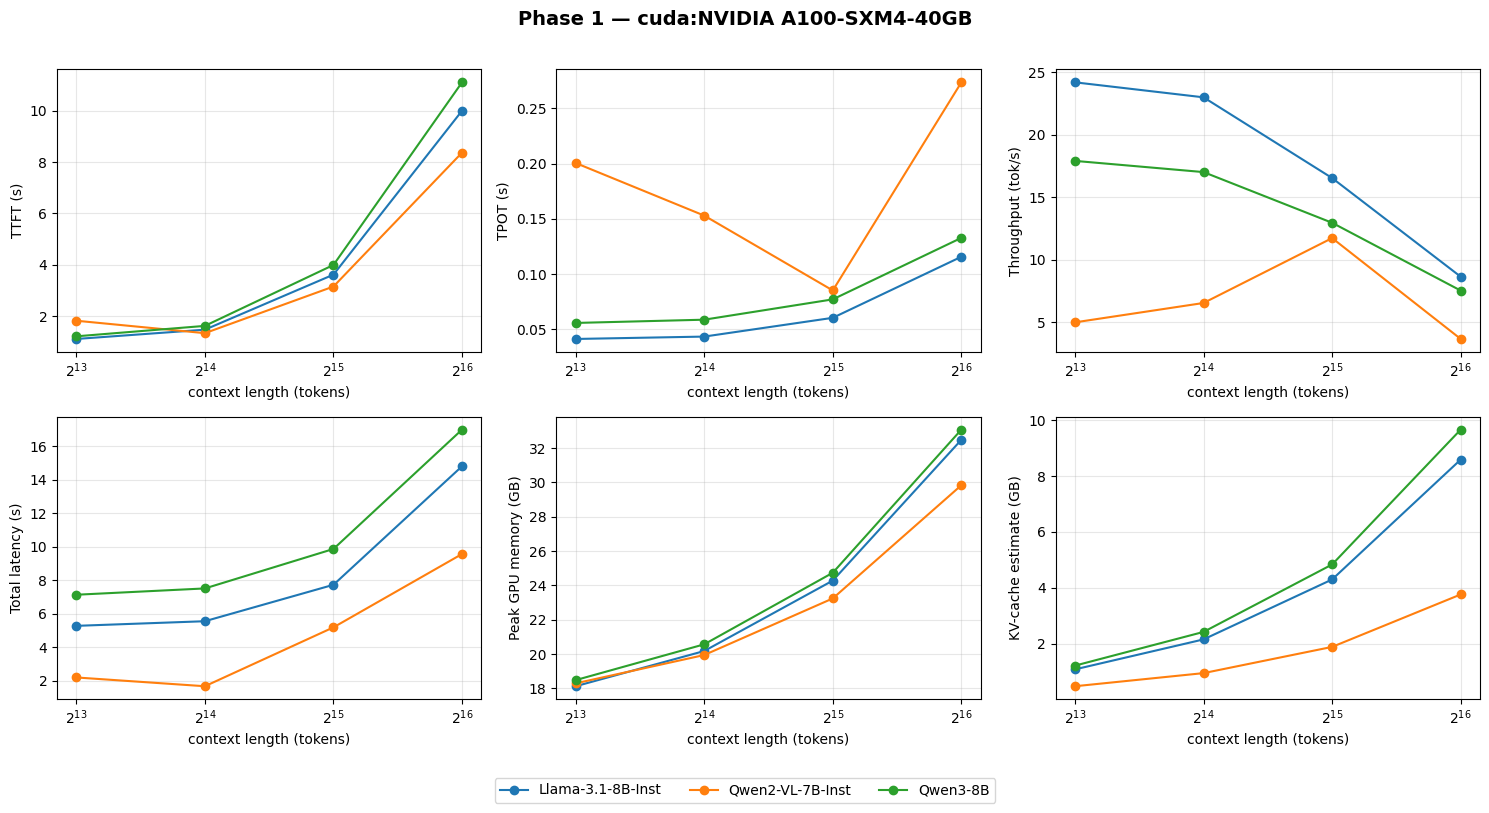

In [12]:
# 10. One 2x3 figure per hardware: TTFT, TPOT, throughput,
#     total latency, peak GPU memory, KV-cache estimate vs context length.
import matplotlib.pyplot as plt
from pathlib import Path

PLOT_DIR = Path('results/plots'); PLOT_DIR.mkdir(parents=True, exist_ok=True)

METRICS = [
    ('ttft_seconds',          'TTFT (s)'),
    ('tpot_seconds',          'TPOT (s)'),
    ('tokens_per_second',     'Throughput (tok/s)'),
    ('total_latency_seconds', 'Total latency (s)'),
    ('peak_gpu_memory_gb',    'Peak GPU memory (GB)'),
    ('kv_cache_memory_gb',    'KV-cache estimate (GB)'),
]

for hw, sub in df.groupby('hardware'):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f'Phase 1 — {hw}', fontsize=14, fontweight='bold')

    for (col, ylabel), ax in zip(METRICS, axes.flat):
        for label, grp in sub.groupby('label'):
            ok   = grp[grp.success == True ].sort_values('context_length')
            fail = grp[grp.success == False].sort_values('context_length')
            line, = ax.plot(ok.context_length, ok[col], marker='o', label=label)
            if len(fail):
                # Place the OOM marker at the y-value the run reached before failing
                # for memory plots; at the bottom of the axis for time plots.
                if col == 'peak_gpu_memory_gb':
                    y = fail[col].fillna(0)
                elif col == 'kv_cache_memory_gb':
                    y = fail[col].fillna(0)
                else:
                    y = [ax.get_ylim()[0]] * len(fail) if ax.has_data() else [0]*len(fail)
                ax.scatter(fail.context_length, y, marker='x', color='red',
                           s=120, zorder=5, linewidths=2.5)
        ax.set_xscale('log', base=2)
        ax.set_xlabel('context length (tokens)')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

    # Single legend at the figure level.
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(labels),
               bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout(rect=(0, 0.04, 1, 0.97))

    safe_hw = hw.replace(':', '_').replace(' ', '_').replace('/', '_')
    out = PLOT_DIR / f'phase1_{safe_hw}.png'
    plt.savefig(out, dpi=120, bbox_inches='tight')
    print(f'saved {out}')
    plt.show()


saved results/plots/frontier_cuda_NVIDIA_A100-SXM4-40GB.png


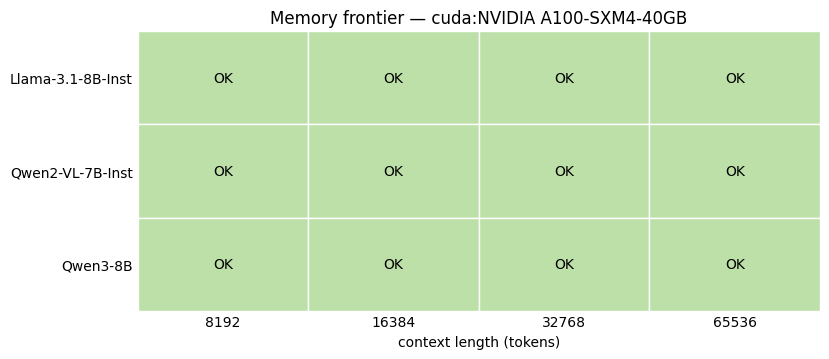

In [13]:
# 11. Success-vs-OOM matrix at a glance: rows = model, cols = context length,
#     filled if the run succeeded, hatched red if OOM. One panel per hardware.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

for hw, sub in df.groupby('hardware'):
    pivot_ok = sub.pivot_table(index='label', columns='context_length',
                               values='success', aggfunc='first')
    if pivot_ok.empty:
        continue
    fig, ax = plt.subplots(figsize=(1.6 * len(pivot_ok.columns) + 2, 0.9 * len(pivot_ok.index) + 1))
    for i, model in enumerate(pivot_ok.index):
        for j, ctx in enumerate(pivot_ok.columns):
            v = pivot_ok.loc[model, ctx]
            color = '#bde0a8' if v == True else ('#f4a8a8' if v == False else '#dddddd')
            ax.add_patch(Rectangle((j, i), 1, 1, facecolor=color, edgecolor='white'))
            label = 'OK' if v == True else ('OOM' if v == False else '-')
            ax.text(j + 0.5, i + 0.5, label, ha='center', va='center', fontsize=10)
    ax.set_xlim(0, len(pivot_ok.columns)); ax.set_ylim(0, len(pivot_ok.index))
    ax.invert_yaxis()
    ax.set_xticks(np.arange(len(pivot_ok.columns)) + 0.5)
    ax.set_xticklabels(pivot_ok.columns)
    ax.set_yticks(np.arange(len(pivot_ok.index)) + 0.5)
    ax.set_yticklabels(pivot_ok.index)
    ax.set_xlabel('context length (tokens)')
    ax.set_title(f'Memory frontier — {hw}')
    ax.tick_params(length=0)
    for spine in ax.spines.values(): spine.set_visible(False)
    plt.tight_layout()
    safe_hw = hw.replace(':', '_').replace(' ', '_').replace('/', '_')
    out = Path('results/plots') / f'frontier_{safe_hw}.png'
    plt.savefig(out, dpi=120, bbox_inches='tight')
    print(f'saved {out}')
    plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'results/plots/t4_fp16_vs_4bit.png'

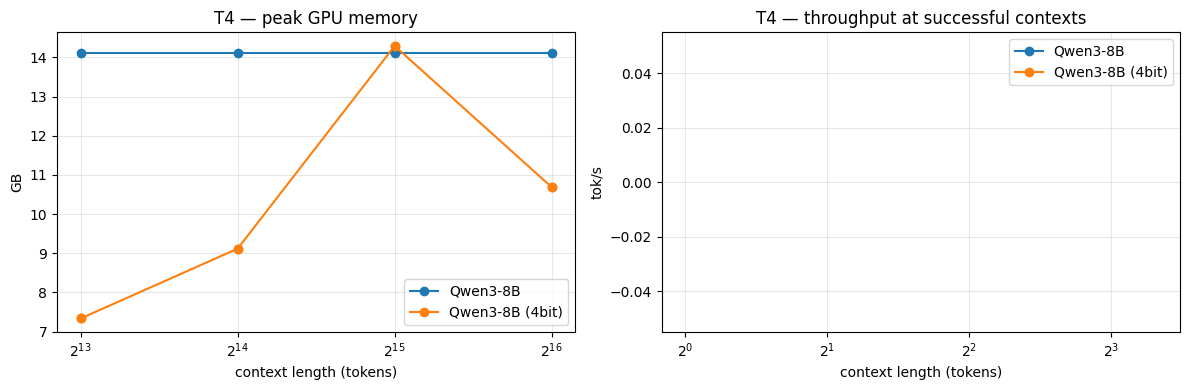

In [38]:
# 12. T4-only: fp16 baseline vs 4-bit extension on Qwen3-8B.
#     Single bar/line comparison of peak GPU memory and "did it fit" so you can
#     show one chart that argues for/against quantization on memory-constrained GPUs.
import matplotlib.pyplot as plt

t4 = df[df.hardware.str.contains('T4', case=False, na=False)]
t4_qwen = t4[t4.label.str.startswith('Qwen3-8B')]
if t4_qwen['label'].nunique() < 2:
    print('Not enough T4 Qwen3 data yet (need both fp16 and 4bit) — skipping comparison.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for label, grp in t4_qwen.groupby('label'):
        grp = grp.sort_values('context_length')
        axes[0].plot(grp.context_length, grp.peak_gpu_memory_gb, marker='o', label=label)
        ok = grp[grp.success == True]
        axes[1].plot(ok.context_length, ok.tokens_per_second, marker='o', label=label)
    for ax in axes: ax.set_xscale('log', base=2); ax.grid(alpha=0.3); ax.legend()
    axes[0].set_title('T4 — peak GPU memory'); axes[0].set_ylabel('GB')
    axes[1].set_title('T4 — throughput at successful contexts'); axes[1].set_ylabel('tok/s')
    for ax in axes: ax.set_xlabel('context length (tokens)')
    plt.tight_layout()
    out = Path('results/plots/t4_fp16_vs_4bit.png')
    plt.savefig(out, dpi=120, bbox_inches='tight')
    print(f'saved {out}')
    plt.show()

In [41]:
!pip install -q nbstripout
!nbstripout notebooks/03_phase1_runner.ipynb
!git add notebooks/03_phase1_runner.ipynb
!git -c user.email="sonavk2@illinois.edu" -c user.name="sonavk2" commit -m "strip notebook widget metadata for github rendering"
!git push

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/01_run_baseline_colab.ipynb
	deleted:    results/baseline_hf.jsonl
	deleted:    results/phase1.jsonl

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	=0.46.1
	results/archive/

no changes added to commit (use "git add" and/or "git commit -a")
fatal: could not read Username for 'https://github.com': No such device or address
